In [107]:
from tradeModul.report import PrintReport
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


# Увеличить максимальное количество отображаемых столбцов
pd.set_option('display.max_columns', None)  # или число, например 50
# Увеличить ширину строки вывода
pd.set_option('display.width', 1000)
# Увеличить максимальное количество символов в ячейке
pd.set_option('display.max_colwidth', None)

reportFileName = "ReportAllResults1.csv"



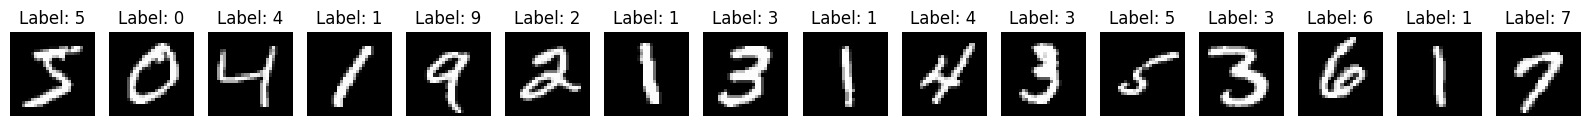

In [108]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Загрузка данных MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Отображение первых 3 изображений
plt.figure(figsize=(16, 8))
  
subrow = 16

for i in range(subrow):
    plt.subplot(1, subrow, i + 1)  
    plt.imshow(x_train[i], cmap='gray')  
    plt.title(f"Label: {y_train[i]}")  
    plt.axis('off') 

plt.tight_layout()  
plt.show()

In [109]:

# # Загрузка данных MNIST
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Преобразование данных: разворачиваем каждое изображение 28x28 в вектор длиной 784
x_train = x_train.reshape(-1, 28 * 28)  # (60000, 784)
x_test = x_test.reshape(-1, 28 * 28)    # (10000, 784)

# Нормализация значений пикселей (приведение к диапазону [0, 1])
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Ограничение количества строк (опционально)
row = 100 
x_train = x_train[:row]
y_train = y_train[:row]
# x_test = x_test[:row]
# y_test = y_test[:row]

print("Start with row="+str(len(x_train)))

Start with row=100


In [110]:
# 2. Классификатор GradientBoost 
from sklearn.ensemble import GradientBoostingClassifier

# Создание и обучение классификатора градиентного бустинга
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
clf.fit(x_train, y_train)

# Прогнозирование и оценка точности
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')

# Вывод полного отчета
report = classification_report(y_test, y_pred)
print(report)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
max_metric, min_metric = PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "GradientBoostingClassifier", len(x_train), accuracy, max_metric, min_metric)

Accuracy: 0.46
              precision    recall  f1-score   support

           0       0.72      0.55      0.62       980
           1       0.66      0.72      0.69      1135
           2       0.48      0.29      0.36      1032
           3       0.54      0.40      0.46      1010
           4       0.48      0.69      0.57       982
           5       0.74      0.22      0.34       892
           6       0.48      0.47      0.48       958
           7       0.53      0.44      0.48      1028
           8       0.26      0.22      0.24       974
           9       0.23      0.54      0.32      1009

    accuracy                           0.46     10000
   macro avg       0.51      0.45      0.46     10000
weighted avg       0.51      0.46      0.46     10000

Confusion Matrix:
[[538   0  24  22  26   4  92  35  57 182]
 [  0 812   2  29   3   2   4  15  85 183]
 [ 29  88 295  33 111   0 206  30 108 132]
 [ 58  51 140 402  78  13  17  28  41 182]
 [ 10  70  10  18 675  12  22  15  2

In [111]:
# 2. Классификатор CatBoost 
from catboost import CatBoostClassifier

# Создание и обучение классификатора CatBoost
clf = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=0)
clf.fit(x_train, y_train)

# Прогнозирование и оценка точности
y_pred = clf.predict(x_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "CatBoostClassifier", len(x_train), accuracy, max_metric, min_metric)


Accuracy: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79       980
           1       0.60      0.98      0.74      1135
           2       0.88      0.36      0.51      1032
           3       0.60      0.81      0.69      1010
           4       0.48      0.81      0.60       982
           5       0.92      0.09      0.16       892
           6       0.74      0.68      0.71       958
           7       0.79      0.76      0.77      1028
           8       0.70      0.45      0.55       974
           9       0.57      0.50      0.53      1009

    accuracy                           0.64     10000
   macro avg       0.70      0.63      0.61     10000
weighted avg       0.69      0.64      0.61     10000

Confusion Matrix:
[[ 877    3    8    3   22    1   42   18    3    3]
 [   0 1112    0    6    3    0    1    1    7    5]
 [  52  296  371   29  169    0   39   21   51    4]
 [  45   64    5  816   11

In [112]:
# 3. DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Создание и обучение классификатора AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1)

base_estimator.fit(x_train, y_train)

# Прогнозирование классов на тестовом наборе данных
y_pred = base_estimator.predict(x_test)

# Оценка модели
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "DecisionTreeClassifier", len(x_train), accuracy, max_metric, min_metric)


Accuracy: 0.14
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.12      0.99      0.21      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.58      0.31      0.40       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.14     10000
   macro avg       0.07      0.13      0.06     10000
weighted avg       0.07      0.14      0.06     10000

Confusion Matrix:
[[   0  952    0    0    0    0   28    0    0    0]
 [   0 1128    0    0    0    0    7    0    0    0]
 [   0  899    0    0    0    0  133    0    0    0]
 [   0  997    0    0    0

/home/gr/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gr/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gr/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gr/.local/lib/py

In [113]:
# 4. AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Создание и обучение классификатора AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1)
ada_classifier = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada_classifier.fit(x_train, y_train)

# Прогнозирование классов на тестовом наборе данных
y_pred = ada_classifier.predict(x_test)

# Оценка модели
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "AdaBoostClassifier", len(x_train), accuracy, max_metric, min_metric)


Accuracy: 0.25
Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.82      0.43       980
           1       0.22      0.59      0.32      1135
           2       0.00      0.00      0.00      1032
           3       0.24      0.01      0.01      1010
           4       0.21      0.80      0.34       982
           5       0.00      0.00      0.00       892
           6       0.64      0.27      0.38       958
           7       0.00      0.00      0.00      1028
           8       0.03      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.25     10000
   macro avg       0.16      0.25      0.15     10000
weighted avg       0.16      0.25      0.15     10000

Confusion Matrix:
[[804  39   0   0 119   0  18   0   0   0]
 [ 18 675   0   0 438   0   1   0   3   0]
 [579 199   0   0 152   0 101   0   1   0]
 [165 740   0   6  91   0   8   0   0   0]
 [104  84   0

/home/gr/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gr/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gr/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gr/.local/lib/py

In [114]:
# 5. ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_val_score
import matplotlib.pyplot as plt

# Создание и обучение классификатора Extra Trees с использованием GridSearchCV для подбора гиперпараметров
param_grid = {
    'n_estimators': [300],
    'max_features': ['log2'],
    'max_depth': [20],
    'min_samples_split': [2]
}

# Инициализация ExtraTreesClassifier
clf = ExtraTreesClassifier(random_state=42)

# Настройка GridSearchCV
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучение модели с подбором гиперпараметров
grid_search.fit(x_train, y_train)

# Вывод лучших параметров и точности
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность (CV):", grid_search.best_score_)

# Использование лучшей модели для прогнозирования
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(x_test)

# Оценка модели
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy на тестовых данных: {accuracy:.2f}')
print('Classification Report:')
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "ExtraTreesClassifier", len(x_train), accuracy, max_metric, min_metric)


# Точность на обучающей выборке для проверки переобучения
y_train_pred = best_clf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f'Training Accuracy: {train_accuracy:.2f}')

# Визуализация важности признаков
feature_importances = best_clf.feature_importances_
indices = np.argsort(feature_importances)[::-1]

# plt.figure(figsize=(144, 72))
# plt.title("Важность признаков для ExtraTreesClassifier")
# plt.bar(range(x_train.shape[1]), feature_importances[indices], align='center')
# plt.xticks(range(x_train.shape[1]), [f'Feature {i}' for i in indices], rotation=90)
# plt.xlabel('Признаки')
# plt.ylabel('Важность')
# plt.tight_layout()
# plt.show()

# Выбор топ-N признаков
n = 10
top_n_indices = indices[:n]
top_n_importances = feature_importances[top_n_indices]

# Вывод топ-N признаков
print("Топ-N важных признаков:")
for i, idx in enumerate(top_n_indices):
    print(f"Признак {idx}: важность = {top_n_importances[i]:.4f}")
    
# Подсчет признаков с важностью 0
zero_importance_count = np.sum(feature_importances == 0)
print(f"\n Количество признаков с важностью 0: {zero_importance_count} \n")

# Кросс-валидация для дополнительной оценки модели
cv_scores = cross_val_score(best_clf, x_train, y_train, cv=5, scoring='accuracy')
print(f'Кросс-валидационные оценки: {cv_scores}')
print(f'Средняя кросс-валидационная точность: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Лучшие параметры: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}
Лучшая точность (CV): 0.8400000000000001
Accuracy на тестовых данных: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       980
           1       0.65      0.98      0.78      1135
           2       0.90      0.44      0.59      1032
           3       0.61      0.83      0.71      1010
           4       0.49      0.80      0.60       982
           5       0.91      0.18      0.30       892
           6       0.74      0.75      0.74       958
           7       0.87      0.77      0.82      1028
           8       0.71      0.52      0.60       974
           9       0.60      0.50      0.55      1009

    accuracy                           0.68     10000
   macro avg       0.72      0.67      0.65     10000
weighted avg       0.72      0.68      0.66     10000

Confusion Matrix:
[[ 900    0    0    

In [115]:
# 6. QDA 
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Создание и обучение классификатора QDA
clf = QuadraticDiscriminantAnalysis()
clf.fit(x_train, y_train)

# Прогнозирование и оценка точности
y_pred = clf.predict(x_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "QuadraticDiscriminantAnalysis", len(x_train), accuracy, max_metric, min_metric)


/home/gr/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/gr/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/gr/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/gr/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.wa

Accuracy: 0.23
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.17      0.25       980
           1       0.46      0.39      0.42      1135
           2       0.11      0.25      0.15      1032
           3       0.20      0.24      0.22      1010
           4       0.23      0.40      0.29       982
           5       0.12      0.11      0.11       892
           6       0.29      0.13      0.18       958
           7       0.31      0.28      0.29      1028
           8       0.38      0.11      0.18       974
           9       0.17      0.15      0.16      1009

    accuracy                           0.23     10000
   macro avg       0.27      0.22      0.23     10000
weighted avg       0.27      0.23      0.23     10000

Confusion Matrix:
[[170  13 244  60 144 129 125  50  16  29]
 [  2 442 515  67  23  21   0  54   1  10]
 [ 63  89 262 128 170 145  10  82  15  68]
 [ 82  33 178 246 158  32  65  76  50  90]
 [  0  58  92

In [116]:
# !pip install lightgbm

In [117]:
# 7. lightgbm
import lightgbm as lgb

# Создание и обучение классификатора LightGBM
clf = lgb.LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=100)
clf.fit(x_train, y_train)

# Прогнозирование и оценка точности
y_pred = clf.predict(x_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "LGBMClassifier", len(x_train), accuracy, max_metric, min_metric)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3689
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 266
[LightGBM] [Info] Start training from score -2.040221
[LightGBM] [Info] Start training from score -1.966113
[LightGBM] [Info] Start training from score -2.813411
[LightGBM] [Info] Start training from score -2.207275
[LightGBM] [Info] Start training from score -2.207275
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.207275
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.525729
[LightGBM] [Info] Start training from score -2.207275
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

/home/gr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [118]:
# 8. Dense
from tensorflow.keras import layers

model = tf.keras.models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),  
    layers.Dropout(0.3),  
    layers.Dense(10, activation='softmax')  
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=15, batch_size=32, validation_split=0.1)

y_pred_prob = model.predict(x_test)  
y_pred = y_pred_prob.argmax(axis=1)  

# Оценка точности
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Вывод отчета
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "Dense_128", len(x_train), accuracy, max_metric, min_metric)



/home/gr/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.1024 - loss: 2.3921 - val_accuracy: 0.3000 - val_loss: 2.0233
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4165 - loss: 1.9546 - val_accuracy: 0.4000 - val_loss: 1.8527
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5652 - loss: 1.6680 - val_accuracy: 0.4000 - val_loss: 1.6624
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6487 - loss: 1.5032 - val_accuracy: 0.5000 - val_loss: 1.4594
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7466 - loss: 1.2481 - val_accuracy: 0.7000 - val_loss: 1.2707
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7594 - loss: 1.1587 - val_accuracy: 0.7000 - val_loss: 1.0763
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8513 - loss: 1.0122 - val_accuracy: 0.7000 - val_loss: 0.9079
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9371 - loss: 0.8257 - val_accuracy: 0.9000 - val_loss: 0.7688

In [119]:
# 9. Conv2D
from tensorflow.keras import layers

model = tf.keras.models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(784,)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),  
    layers.MaxPooling2D(pool_size=(2, 2)), 
    layers.Flatten(),  
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=15, batch_size=32, validation_split=0.1)

# Прогнозирование
y_pred_prob = model.predict(x_test)  
y_pred = y_pred_prob.argmax(axis=1)  # Индексы максимальных вероятностей

# Оценка точности
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Вывод отчета
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "Conv2D_32", len(x_train), accuracy, max_metric, min_metric)


/home/gr/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.1286 - loss: 2.2885 - val_accuracy: 0.4000 - val_loss: 1.8939
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5039 - loss: 1.8340 - val_accuracy: 0.6000 - val_loss: 1.5253
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6514 - loss: 1.5165 - val_accuracy: 0.7000 - val_loss: 1.2031
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7411 - loss: 1.2081 - val_accuracy: 0.7000 - val_loss: 0.9197
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7756 - loss: 0.9072 - val_accuracy: 0.8000 - val_loss: 0.6949
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8040 - loss: 0.7675 - val_accuracy: 0.9000 - val_loss: 0.4930
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8986 - loss: 0.6046 - val_accuracy: 0.9000 - val_loss: 0.3242
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9432 - loss: 0.4042 - val_accuracy: 1.0000 - val_loss: 0.2011

In [120]:
# 9. Conv2D
from tensorflow.keras import layers

model = tf.keras.models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(784,)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),  
    layers.MaxPooling2D(pool_size=(2, 2)), 
    layers.Flatten(),  
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=8, batch_size=32, validation_split=0.1)

# Прогнозирование
y_pred_prob = model.predict(x_test)  
y_pred = y_pred_prob.argmax(axis=1)  # Индексы максимальных вероятностей

# Оценка точности
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Вывод отчета
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Поиск самой высокой и низкой метрики
PrintReport.print_min_max_metric(y_test, y_pred)
PrintReport.save_test_results(reportFileName, "Conv2D_32", len(x_train), accuracy, max_metric, min_metric)


Epoch 1/8


/home/gr/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.1253 - loss: 2.2927 - val_accuracy: 0.6000 - val_loss: 1.9388
Epoch 2/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4916 - loss: 1.8599 - val_accuracy: 0.6000 - val_loss: 1.5287
Epoch 3/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6787 - loss: 1.4258 - val_accuracy: 0.8000 - val_loss: 1.1162
Epoch 4/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8046 - loss: 1.0456 - val_accuracy: 0.8000 - val_loss: 0.7768
Epoch 5/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8786 - loss: 0.8355 - val_accuracy: 0.9000 - val_loss: 0.5130
Epoch 6/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9227 - loss: 0.5499 - val_accuracy: 0.9000 - val_loss: 0.3735
Epoch 7/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9416 - loss: 0.3761 - val_accuracy: 0.9000 - val_loss: 0.2882
Epoch 8/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9009 - loss: 0.3670 - val_accuracy: 0.9000 - val_loss: 0.2180
313/313 ━━━━━━━━━

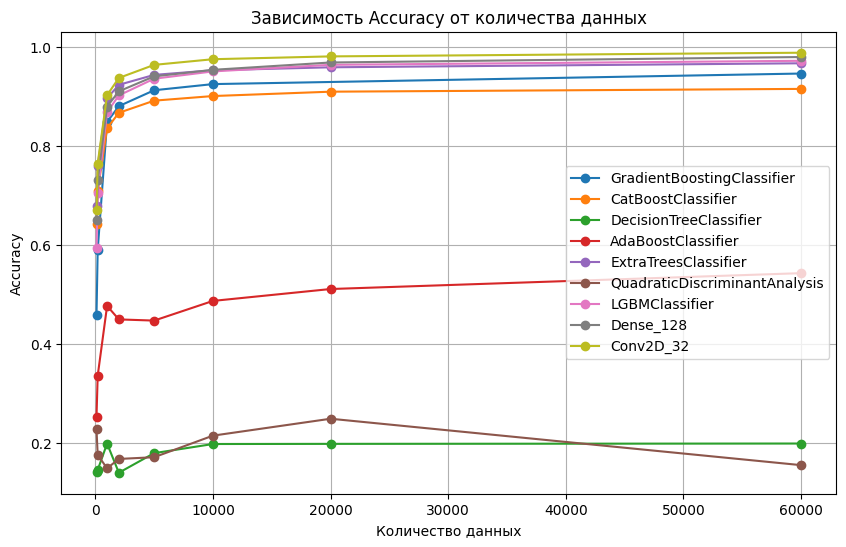

In [ ]:
PrintReport.plot_accuracy_vs_data_size("ReportAllResults.csv")